In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw" / "geolife").is_dir():
            return candidate
    raise FileNotFoundError(
        "GeoLife dataset not found under data/raw/geolife."
    )

project_root = find_project_root(Path.cwd())
root = project_root / "data" / "raw" / "geolife"

trajectory_files = sorted(root.rglob("*.plt"))

if not trajectory_files:
    raise FileNotFoundError(f"No .plt trajectory files found under {root}")

print("Trajectory files:", len(trajectory_files))

Trajectory files: 18670


In [19]:
trajectory_files = sorted(root.rglob("*.plt"))

user_directories = sorted({
    file.parent.parent.name
    for file in trajectory_files
})

print("Trajectory files:", len(trajectory_files))
print("User directories:", len(user_directories))
print(
    "First trajectory:",
    trajectory_files[0] if trajectory_files else "None"
)
print("First users:", user_directories[:10])

Trajectory files: 18670
User directories: 182
First trajectory: C:\Users\Yash Tyagi\OneDrive\Desktop\WEGOTCHU\data\raw\geolife\Geolife Trajectories 1.3\Data\000\Trajectory\20081023025304.plt
First users: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009']


In [20]:
columns = [
    "latitude",
    "longitude",
    "unused",
    "altitude_feet",
    "days",
    "date",
    "time",
]

sample_file = trajectory_files[0]

sample_df = pd.read_csv(
    sample_file,
    skiprows=6,
    header=None,
    names=columns,
)

sample_df["timestamp"] = pd.to_datetime(
    sample_df["date"].astype(str) + " " + sample_df["time"].astype(str),
    errors="coerce",
)

# GeoLife stores altitude in feet; -777 indicates missing altitude.
sample_df["altitude_feet"] = sample_df["altitude_feet"].replace(-777, np.nan)
sample_df["altitude_meters"] = sample_df["altitude_feet"] * 0.3048

sample_df.head()

,latitude,longitude,unused,altitude_feet,days,date,time,timestamp,altitude_meters
0,39.984702,116.318417,0,492,39744.120185,2008-10-23,02:53:04,2008-10-23 02:53:04,149.9616
1,39.984683,116.318450,0,492,39744.120255,2008-10-23,02:53:10,2008-10-23 02:53:10,149.9616
2,39.984686,116.318417,0,492,39744.120313,2008-10-23,02:53:15,2008-10-23 02:53:15,149.9616
3,39.984688,116.318385,0,492,39744.120370,2008-10-23,02:53:20,2008-10-23 02:53:20,149.9616
4,39.984655,116.318263,0,492,39744.120428,2008-10-23,02:53:25,2008-10-23 02:53:25,149.9616


In [21]:
sample_df.shape

(908, 9)

In [22]:
sample_df.dtypes

latitude                  float64
longitude                 float64
unused                      int64
altitude_feet               int64
days                      float64
date                          str
time                          str
timestamp          datetime64[us]
altitude_meters           float64
dtype: object

In [23]:
print("Missing values:")
display(sample_df.isna().sum())

print("Duplicate rows:", sample_df.duplicated().sum())
print("Duplicate timestamps:", sample_df["timestamp"].duplicated().sum())

Missing values:


latitude           0
longitude          0
unused             0
altitude_feet      0
days               0
date               0
time               0
timestamp          0
altitude_meters    0
dtype: int64

Duplicate rows: 0
Duplicate timestamps: 0


In [24]:
invalid_latitude = (
    (sample_df["latitude"] < -90) |
    (sample_df["latitude"] > 90)
).sum()

invalid_longitude = (
    (sample_df["longitude"] < -180) |
    (sample_df["longitude"] > 180)
).sum()

print("Invalid latitude values:", invalid_latitude)
print("Invalid longitude values:", invalid_longitude)

Invalid latitude values: 0
Invalid longitude values: 0


In [25]:
ordered = sample_df.sort_values("timestamp").copy()

gaps = (
    ordered["timestamp"]
    .diff()
    .dt.total_seconds()
    .dropna()
)

print(gaps.describe())
print("Gaps greater than 60 seconds:", (gaps > 60).sum())
print("Gaps greater than 5 minutes:", (gaps > 300).sum())
print("Largest gap in seconds:", gaps.max())

count      907.000000
mean        32.952591
std        627.101101
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      18453.000000
Name: timestamp, dtype: float64
Gaps greater than 60 seconds: 9
Gaps greater than 5 minutes: 6
Largest gap in seconds: 18453.0


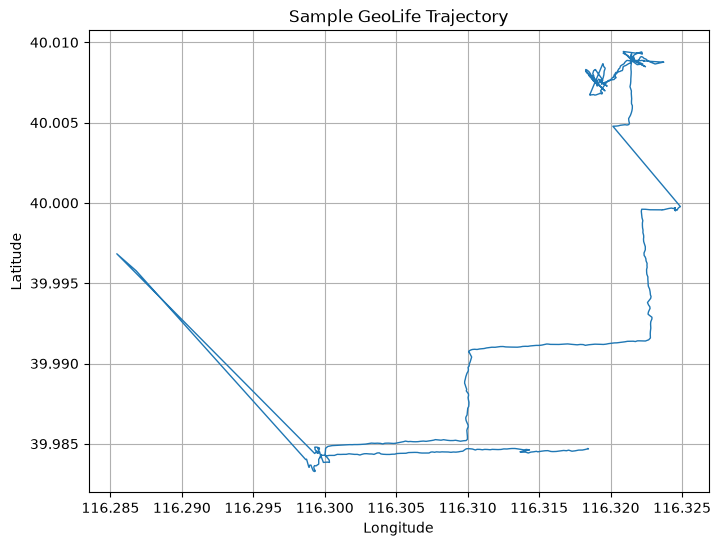

In [26]:
plt.figure(figsize=(8, 6))

plt.plot(
    sample_df["longitude"],
    sample_df["latitude"],
    linewidth=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample GeoLife Trajectory")
plt.grid(True)
plt.show()

In [ ]:
## Data Quality Findings

The inspected trajectory contains 908 observations with no missing values, duplicate rows, duplicate timestamps, or invalid coordinates.

However, timestamp intervals are irregular. Nine gaps exceed 60 seconds, six gaps exceed five minutes, and the largest gap is 18,453 seconds (approximately 5.1 hours). Therefore, preprocessing must detect large temporal gaps and must not connect points across such gaps as if continuous movement occurred.

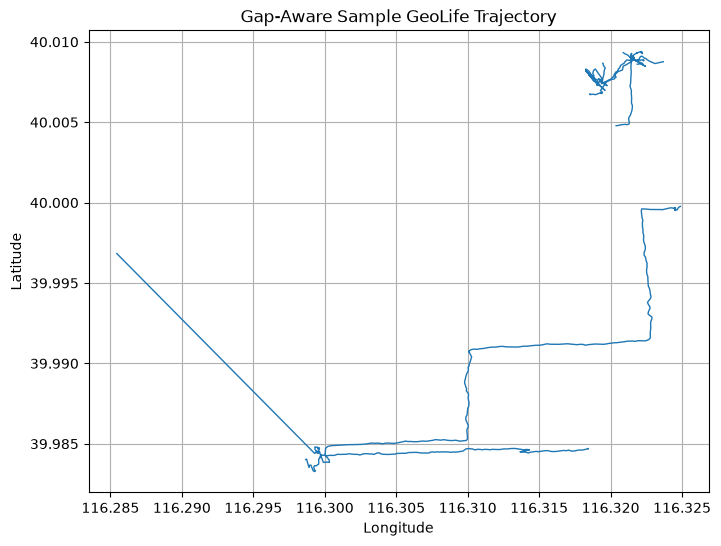

In [27]:
plot_df = sample_df.sort_values("timestamp").copy()

plot_df["gap_seconds"] = (
    plot_df["timestamp"]
    .diff()
    .dt.total_seconds()
)

plot_df.loc[
    plot_df["gap_seconds"] > 60,
    ["latitude", "longitude"]
] = np.nan

plt.figure(figsize=(8, 6))

plt.plot(
    plot_df["longitude"],
    plot_df["latitude"],
    linewidth=1
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Gap-Aware Sample GeoLife Trajectory")
plt.grid(True)
plt.show()

In [28]:
trajectory_counts = (
    pd.Series(
        [file.parent.parent.name for file in trajectory_files],
        name="user_id"
    )
    .value_counts()
    .sort_index()
)

print("Number of users:", trajectory_counts.size)
print("Minimum trajectories per user:", trajectory_counts.min())
print("Median trajectories per user:", trajectory_counts.median())
print("Maximum trajectories per user:", trajectory_counts.max())

display(trajectory_counts.head(20))

Number of users: 182
Minimum trajectories per user: 1
Median trajectories per user: 27.5
Maximum trajectories per user: 2153


user_id
000    171
001     71
002    175
003    322
004    395
005     86
006     28
007     54
008     34
009     49
010    161
011    201
012     77
013    144
014    279
015     67
016     51
017    391
018     50
019     84
Name: count, dtype: int64

In [ ]:
## Repeated Trajectory Availability

The dataset contains 182 users. The number of trajectories per user is highly unequal, ranging from 1 to 2,153, with a median of 27.5 trajectories per user.

This supports personalized modeling for users with sufficient historical trajectories, but users with very little history require a cold-start fallback. The experiment must report how many users meet the minimum-history requirement.

In [29]:
for minimum in [2, 5, 10, 20]:
    usable_users = (trajectory_counts >= minimum).sum()
    print(
        f"Users with at least {minimum} trajectories: "
        f"{usable_users} / {len(trajectory_counts)}"
    )

Users with at least 2 trajectories: 175 / 182
Users with at least 5 trajectories: 160 / 182
Users with at least 10 trajectories: 131 / 182
Users with at least 20 trajectories: 107 / 182


In [ ]:
## Personalization Eligibility

Using a provisional minimum-history threshold of 5 trajectories, 160 of 182 users are eligible for personalized evaluation. The remaining 22 users do not have enough historical trajectories and should use a cold-start fallback.

The threshold of 5 is an initial experimental choice and must be reported clearly. It may be revised after preprocessing and baseline evaluation.

In [30]:
label_files = sorted(root.rglob("labels.txt"))

print("Label files found:", len(label_files))
print(label_files[:5])

Label files found: 69
[WindowsPath('C:/Users/Yash Tyagi/OneDrive/Desktop/WEGOTCHU/data/raw/geolife/Geolife Trajectories 1.3/Data/010/labels.txt'), WindowsPath('C:/Users/Yash Tyagi/OneDrive/Desktop/WEGOTCHU/data/raw/geolife/Geolife Trajectories 1.3/Data/020/labels.txt'), WindowsPath('C:/Users/Yash Tyagi/OneDrive/Desktop/WEGOTCHU/data/raw/geolife/Geolife Trajectories 1.3/Data/021/labels.txt'), WindowsPath('C:/Users/Yash Tyagi/OneDrive/Desktop/WEGOTCHU/data/raw/geolife/Geolife Trajectories 1.3/Data/052/labels.txt'), WindowsPath('C:/Users/Yash Tyagi/OneDrive/Desktop/WEGOTCHU/data/raw/geolife/Geolife Trajectories 1.3/Data/053/labels.txt')]


In [31]:
if label_files:
    print(label_files[0].read_text(
        encoding="utf-8",
        errors="replace"
    )[:1000])
else:
    print("No labels.txt files found")

Start Time	End Time	Transportation Mode
2007/06/26 11:32:29	2007/06/26 11:40:29	bus
2008/03/28 14:52:54	2008/03/28 15:59:59	train
2008/03/28 16:00:00	2008/03/28 22:02:00	train
2008/03/29 01:27:50	2008/03/29 15:59:59	train
2008/03/29 16:00:00	2008/03/30 15:59:59	train
2008/03/30 16:00:00	2008/03/31 03:13:11	train
2008/03/31 04:17:59	2008/03/31 15:31:06	train
2008/03/31 16:00:08	2008/03/31 16:09:01	taxi
2008/03/31 17:26:04	2008/04/01 00:35:26	train
2008/04/01 00:48:32	2008/04/01 00:59:23	taxi
2008/04/01 01:00:22	2008/04/01 01:08:13	walk
2008/04/01 03:46:35	2008/04/01 03:54:28	taxi
2008/04/01 04:15:38	2008/04/01 11:06:16	train
2008/04/01 11:22:47	2008/04/01 11:28:39	taxi
2008/04/01 11:30:37	2008/04/01 11:35:35	walk
2008/04/02 06:09:26	2008/04/02 06:28:25	walk
2008/04/02 06:30:57	2008/04/02 06:34:20	taxi
2008/04/02 11:24:21	2008/04/02 11:50:45	bus
2008/04/03 01:07:03	2008/04/03 11:31:55	train
2008/04/03 11:32:24	2008/04/03 11:46:14	walk
2008/04/03 11:47:14	2008/04/03 11:55:07	taxi
2008/04/

In [32]:
all_labels = []

for label_file in label_files:
    try:
        labels = pd.read_csv(
            label_file,
            sep="\t",
            header=0
        )

        labels["user_id"] = label_file.parent.name
        all_labels.append(labels)

    except Exception as error:
        print("Could not read:", label_file)
        print(error)

labels_df = pd.concat(all_labels, ignore_index=True)

print("Total label rows:", len(labels_df))
print("Users with labels:", labels_df["user_id"].nunique())
print("Columns:", labels_df.columns.tolist())

display(labels_df.head())

Total label rows: 14718
Users with labels: 69
Columns: ['Start Time', 'End Time', 'Transportation Mode', 'user_id']


,Start Time,End Time,Transportation Mode,user_id
0,2007/06/26 11:32:29,2007/06/26 11:40:29,bus,010
1,2008/03/28 14:52:54,2008/03/28 15:59:59,train,010
2,2008/03/28 16:00:00,2008/03/28 22:02:00,train,010
3,2008/03/29 01:27:50,2008/03/29 15:59:59,train,010
4,2008/03/29 16:00:00,2008/03/30 15:59:59,train,010


In [33]:
print(
    labels_df["Transportation Mode"]
    .value_counts()
)

Transportation Mode
walk          6460
bus           2853
bike          2089
taxi          1179
car            993
subway         813
train          299
airplane        17
boat             7
run              6
motorcycle       2
Name: count, dtype: int64
